In [46]:
# ── CELL 1: IMPORTS & GLOBAL CONFIGURATIONS ───────────────────────────────────
import sys, os
# Add your custom project path to sys.path
sys.path.append("/home/group4/Transformers_Nathalia/project/Output_data/")

import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Custom project imports
from learning.dataset import PixelSetData
from models.stclassifier import PseTae

# Global training parameters
BATCH_SIZE = 64
N_EPOCHS   = 35
LR         = 0.0001  # FIXED: Lowered to 1e-4 for stable Transformer attention
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# The absolute, unchanging order of the 17 bands as they come out of PixelSetData

MASTER_BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'EVI', 'EVI2', 'NDVI', 'NDWI', 'SAVI']

configs = [
    {
        "model_name": "PseTae_5x5_allyear_Spectral",
        "folder": "/home/group4/Transformers_Nathalia/project/Output_data/train_spectral", 
        "test_folder": "/home/group4/Transformers_Nathalia/project/Output_data/test_spectral", 
        "npixel": 25,  
        "n_classes": 19,
        "bands": ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
    },
    {
        "model_name": "PseTae_5x5_allyear_Vegetation",
        "folder": "/home/group4/Transformers_Nathalia/project/Output_data/train_vegetation", 
        "test_folder": "/home/group4/Transformers_Nathalia/project/Output_data/test_vegetation", 
        "npixel": 25,  
        "n_classes": 19,
        "bands": ['EVI', 'EVI2', 'NDVI', 'NDWI', 'SAVI']
    },
    {
        "model_name": "PseTae_5x5_allyear_Allbands",
        "folder": "/home/group4/Transformers_Nathalia/project/Output_data/train_allbands", 
        "test_folder": "/home/group4/Transformers_Nathalia/project/Output_data/test_allbands", 
        "npixel": 25,  
        "n_classes": 19,
        "bands": ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'EVI', 'EVI2', 'NDVI', 'NDWI', 'SAVI']
    }
]

Using device: cuda


In [47]:
import os
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from sklearn.model_selection import train_test_split

def prepare_dataloaders(data_folder, npixel, n_classes, batch_size=64, device='cuda'):
    with open(os.path.join(data_folder, 'normalisation_values.pkl'), 'rb') as f:
        norm = pickle.load(f)

    full_dataset = PixelSetData(folder=data_folder, labels="l3_species", npixel=npixel, norm=norm)
    
    all_idx = list(range(len(full_dataset)))
    all_labels = [int(full_dataset[i][1].item()) for i in all_idx]
    
    train_idx, temp_idx, train_labels, temp_labels = train_test_split(
        all_idx, all_labels, test_size=0.30, random_state=42, stratify=all_labels
    )
    
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.50, random_state=42, stratify=temp_labels
    )

    # Calculate Inverse Frequency Weights
    class_counts = np.bincount(train_labels, minlength=n_classes).astype(np.float32)
    class_weights = torch.tensor(1.0 / (class_counts + 1e-6), dtype=torch.float32).to(device)
    
    # Sampler
    sample_weights = [class_weights[l].item() for l in train_labels]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    loaders = {
        'train': DataLoader(Subset(full_dataset, train_idx), batch_size=batch_size, sampler=sampler, num_workers=2),
        'val': DataLoader(Subset(full_dataset, val_idx), batch_size=batch_size, shuffle=False, num_workers=2),
        'test': DataLoader(Subset(full_dataset, test_idx), batch_size=batch_size, shuffle=False, num_workers=2)
    }
    
    # Return full_dataset so we can access date_positions later
    return loaders, class_weights, full_dataset

def run_epoch(loader, model, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_targets = [], []
    
    with torch.set_grad_enabled(train):
        for batch in loader:
            # FIX: Changed to expect 2 items instead of 3
            (x, mask), y = batch
            
            x, mask, y = x.float().to(device), mask.to(device), y.to(device)

            out = model((x, mask))
            loss = criterion(out, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            else:
                all_preds.extend(out.argmax(1).cpu().numpy())
                all_targets.extend(y.cpu().numpy())

            total_loss += loss.item() * len(y)
            correct += (out.argmax(1) == y).sum().item()
            total += len(y)

    # Diagnostic Output
    if not train and len(all_preds) > 0:
        pred_counts = np.bincount(all_preds, minlength=out.shape[1])
        print(f"\nUnique classes predicted: {np.count_nonzero(pred_counts)}")
        print(f"Distribution: {list(pred_counts)}")

    return total_loss / total, correct / total


Starting Training: PseTae_5x5_allyear_Spectral
DEBUG: Loaded 26212 training samples.
DEBUG: Input data shape is torch.Size([64, 8, 10, 25])

Unique classes predicted: 12
Distribution: [3, 0, 679, 1230, 0, 0, 0, 0, 42, 14, 602, 8, 889, 242, 0, 193, 100, 0, 1615]
Epoch 001/35 | Train Loss: 2.1865 (Acc: 17.64%) | Val Loss: 2.6208 (Acc: 6.16%) | LR: 0.000100

Unique classes predicted: 10
Distribution: [0, 0, 884, 978, 0, 0, 0, 0, 56, 36, 758, 0, 971, 366, 0, 50, 398, 0, 1120]

Unique classes predicted: 12
Distribution: [1, 0, 744, 808, 1, 0, 0, 0, 104, 62, 643, 0, 1040, 481, 0, 45, 423, 0, 1265]

Unique classes predicted: 12
Distribution: [2, 0, 678, 729, 1, 0, 0, 0, 178, 134, 574, 0, 1154, 447, 0, 57, 463, 0, 1200]

Unique classes predicted: 12
Distribution: [0, 0, 680, 716, 37, 1, 0, 0, 369, 168, 429, 0, 933, 646, 0, 120, 486, 0, 1032]
Epoch 005/35 | Train Loss: 0.9435 (Acc: 34.86%) | Val Loss: 2.2155 (Acc: 11.70%) | LR: 0.000095

Unique classes predicted: 14
Distribution: [5, 0, 751, 9


Unique classes predicted: 17
Distribution: [69, 0, 615, 502, 252, 84, 185, 0, 712, 207, 177, 332, 530, 374, 77, 324, 385, 214, 578]

Unique classes predicted: 18
Distribution: [138, 1, 1058, 631, 99, 60, 47, 0, 533, 248, 474, 150, 425, 417, 75, 114, 95, 44, 1008]

Unique classes predicted: 14
Distribution: [5, 2, 1718, 889, 15, 0, 0, 0, 118, 47, 6, 58, 17, 218, 125, 0, 87, 0, 2312]

Unique classes predicted: 18
Distribution: [158, 1, 559, 342, 255, 129, 201, 0, 742, 268, 155, 344, 596, 348, 174, 277, 316, 204, 548]
Epoch 020/35 | Train Loss: 0.6691 (Acc: 49.35%) | Val Loss: 1.9110 (Acc: 28.15%) | LR: 0.000039

Unique classes predicted: 18
Distribution: [189, 0, 551, 360, 263, 149, 187, 3, 731, 257, 245, 304, 458, 393, 203, 215, 291, 180, 638]

Unique classes predicted: 18
Distribution: [96, 1, 1539, 904, 50, 16, 5, 0, 142, 125, 181, 118, 77, 435, 308, 34, 89, 5, 1492]

Unique classes predicted: 19
Distribution: [165, 2, 688, 309, 260, 153, 197, 9, 767, 239, 164, 310, 568, 368, 188, 29


Unique classes predicted: 19
Distribution: [362, 197, 244, 122, 281, 217, 416, 412, 469, 255, 60, 453, 139, 260, 545, 391, 313, 264, 217]

Unique classes predicted: 19
Distribution: [378, 197, 272, 101, 266, 198, 414, 376, 523, 255, 50, 449, 162, 294, 560, 383, 314, 258, 167]
Epoch 035/35 | Train Loss: 0.4043 (Acc: 66.65%) | Val Loss: 1.2953 (Acc: 53.75%) | LR: 0.000000
✅ Training Complete: PseTae_5x5_allyear_Allbands saved successfully.

📊 Generating combined plots...


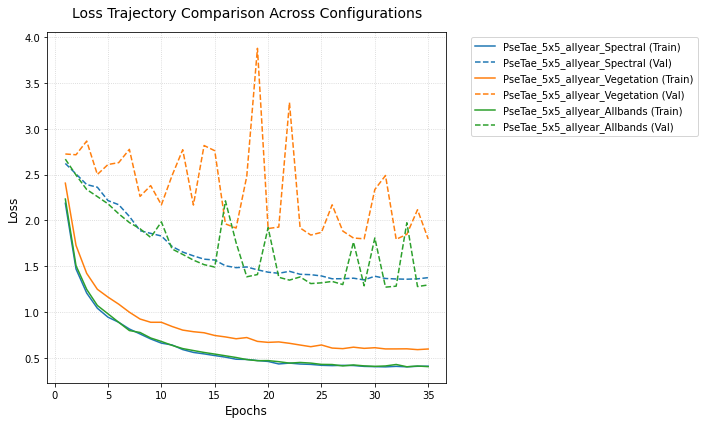

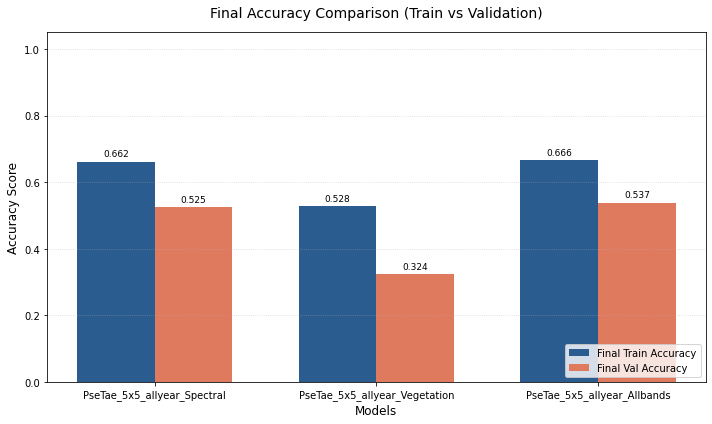

In [48]:
# 3. Execution Loop
training_history = {}
for run in configs:
    model_name = run['model_name']
    print(f"\n{'='*20}\nStarting Training: {model_name}\n{'='*20}")
    
    # 1. Confirm Data and Weights (Updated to receive full_dataset)
    loaders, class_weights, full_dataset = prepare_dataloaders(run["folder"], run["npixel"], run["n_classes"], device=DEVICE)
    print(f"DEBUG: Loaded {len(loaders['train'].dataset)} training samples.")
    
    # Get a single batch to check the dimensions
    sample_batch = next(iter(loaders['train']))
    x, mask = sample_batch[0]
    print(f"DEBUG: Input data shape is {x.shape}")
    
    # 2. Model Initialization (Fixed string key access)
    model = PseTae(
        input_dim=len(run["bands"]),
        mlp1=[len(run["bands"]), 32, 64],
        pooling='mean_std',
        mlp2=[128, 128],
        with_extra=False,
        n_head=4,
        d_k=32,
        mlp3=[512, 128, 128],
        dropout=0.2,
        T=1000,
        len_max_seq=8,
        positions=full_dataset.date_positions, # Now accessible
        mlp4=[128, 64, 32, run["n_classes"]]
    ).to(DEVICE)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    
    training_history[model_name] = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    # 3. Training Loop
    for epoch in range(N_EPOCHS):
        train_loss, train_acc = run_epoch(loaders['train'], model, criterion, optimizer, DEVICE, train=True)
        val_loss, val_acc     = run_epoch(loaders['val'], model, criterion, optimizer, DEVICE, train=False)
        scheduler.step()
        
        training_history[model_name]['train_loss'].append(train_loss)
        training_history[model_name]['val_loss'].append(val_loss)
        training_history[model_name]['train_acc'].append(train_acc)
        training_history[model_name]['val_acc'].append(val_acc)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:03d}/{N_EPOCHS} | "
                  f"Train Loss: {train_loss:.4f} (Acc: {train_acc:.2%}) | "
                  f"Val Loss: {val_loss:.4f} (Acc: {val_acc:.2%}) | "
                  f"LR: {scheduler.get_last_lr()[0]:.6f}")

    # 4. Final Cleanup Confirmation
    # SAVE AS DICT INSTEAD OF STATE_DICT
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'config': run,
        'date_positions': full_dataset.date_positions
    }
    torch.save(checkpoint, f"./{model_name}_best.pth")
    print(f"✅ Training Complete: {model_name} saved successfully.")
    
    del model, optimizer, scheduler, criterion
    torch.cuda.empty_cache()


# ── GENERATE VISUALIZATIONS ───────────────────────────────────────────────────
print("\n📊 Generating combined plots...")

# PLOT 1: Single Line Plot for Losses
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (model_name, metrics) in enumerate(training_history.items()):
    color = colors[i % len(colors)]
    epochs_range = range(1, N_EPOCHS + 1)
    plt.plot(epochs_range, metrics['train_loss'], label=f"{model_name} (Train)", color=color, linestyle='-')
    plt.plot(epochs_range, metrics['val_loss'], label=f"{model_name} (Val)", color=color, linestyle='--')

plt.title("Loss Trajectory Comparison Across Configurations", fontsize=14, pad=15)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("all_models_loss_comparison.png", dpi=300)
plt.show() 

# PLOT 2: Grouped Bar Chart for Final Accuracies
model_names = list(training_history.keys())
final_train_accs = [training_history[m]['train_acc'][-1] for m in model_names]
final_val_accs = [training_history[m]['val_acc'][-1] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10, 6))
bars_train = plt.bar(x - width/2, final_train_accs, width, label='Final Train Accuracy', color='#2b5c8f')
bars_val = plt.bar(x + width/2, final_val_accs, width, label='Final Val Accuracy', color='#e07a5f')

plt.title("Final Accuracy Comparison (Train vs Validation)", fontsize=14, pad=15)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xticks(x, model_names)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend(loc='lower right')

for bar in bars_train + bars_val:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("all_models_accuracy_comparison.png", dpi=300)
plt.show()

In [59]:
name_map = {
    "PseTae_5x5_allyear_Spectral": "Spectral Only",
    "PseTae_5x5_allyear_Vegetation": "Vegetation Only",
    "PseTae_5x5_allyear_Allbands": "Combined Bands"
}


📊 Generating combined plots...


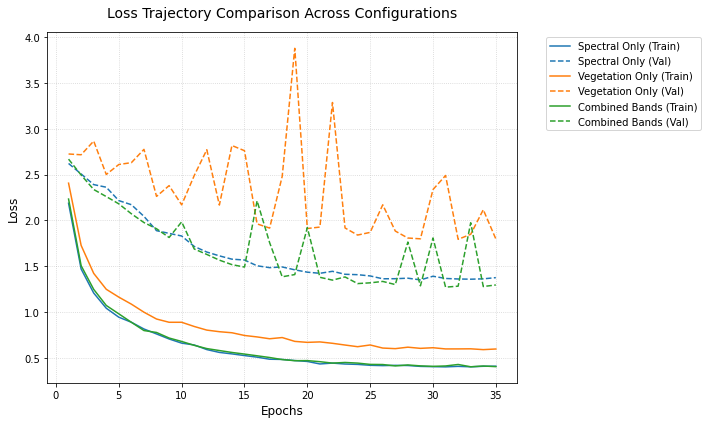

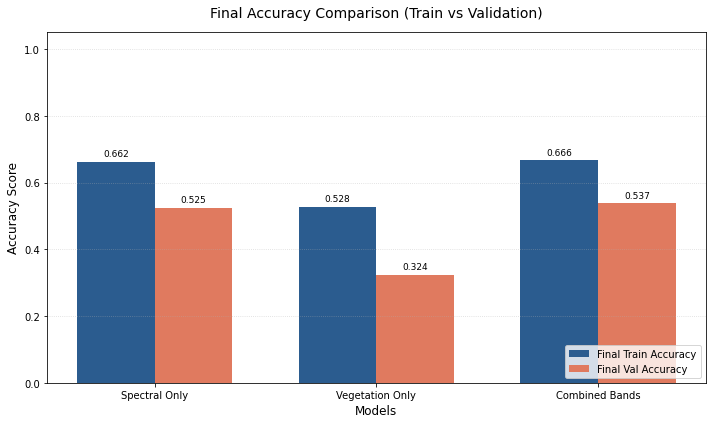

In [60]:
# ── GENERATE VISUALIZATIONS ───────────────────────────────────────────────────
print("\n📊 Generating combined plots...")

# PLOT 1: Single Line Plot for Losses
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (model_name, metrics) in enumerate(training_history.items()):
    # Get friendly name
    display_name = name_map.get(model_name, model_name)
    
    color = colors[i % len(colors)]
    epochs_range = range(1, N_EPOCHS + 1)
    
    # Update labels to use display_name
    plt.plot(epochs_range, metrics['train_loss'], label=f"{display_name} (Train)", color=color, linestyle='-')
    plt.plot(epochs_range, metrics['val_loss'], label=f"{display_name} (Val)", color=color, linestyle='--')

plt.title("Loss Trajectory Comparison Across Configurations", fontsize=14, pad=15)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("all_models_loss_comparison.png", dpi=300)
plt.show() 

# PLOT 2: Grouped Bar Chart for Final Accuracies
model_names = list(training_history.keys())
# Update names for the X-axis labels
friendly_names = [name_map.get(m, m) for m in model_names]

final_train_accs = [training_history[m]['train_acc'][-1] for m in model_names]
final_val_accs = [training_history[m]['val_acc'][-1] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10, 6))
bars_train = plt.bar(x - width/2, final_train_accs, width, label='Final Train Accuracy', color='#2b5c8f')
bars_val = plt.bar(x + width/2, final_val_accs, width, label='Final Val Accuracy', color='#e07a5f')

plt.title("Final Accuracy Comparison (Train vs Validation)", fontsize=14, pad=15)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)

# Use friendly_names here
plt.xticks(x, friendly_names) 

plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend(loc='lower right')

for bar in bars_train + bars_val:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("all_models_accuracy_comparison.png", dpi=300)
plt.show()

<ipython-input-63-863fe4333132>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f"./{run['model_name']}_best.pth", map_location=DEVICE)



📊 Generating Evaluation Plots...


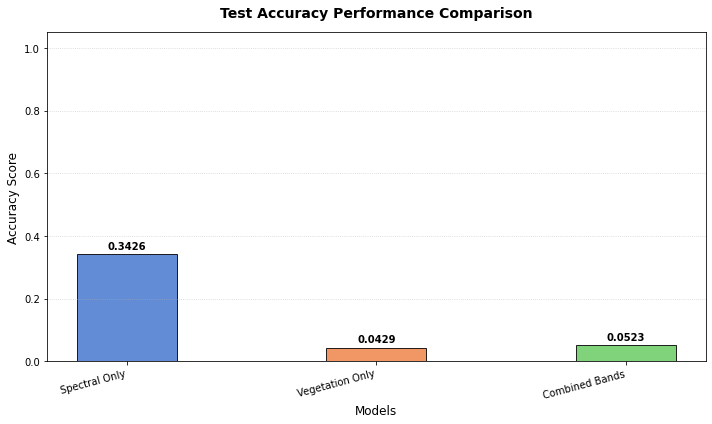

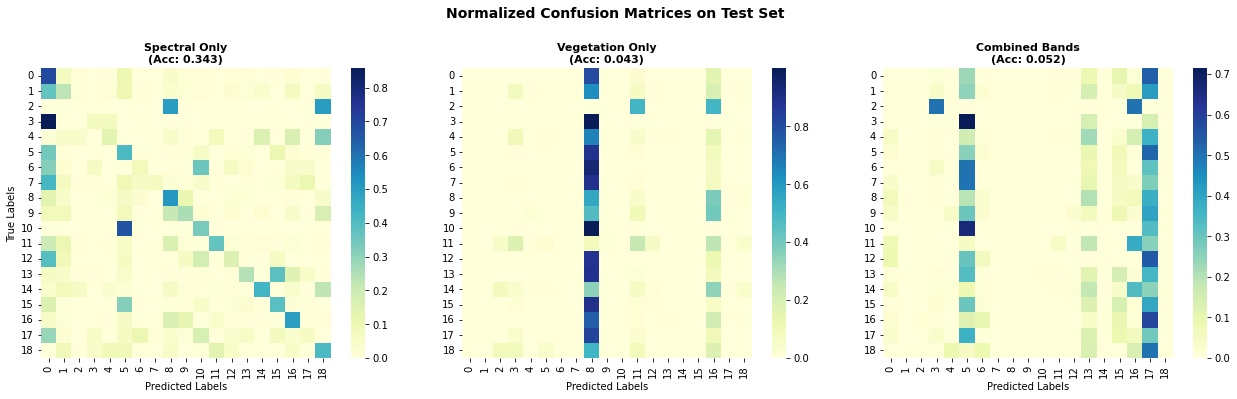

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

test_results = {}
for run in configs:
    checkpoint = torch.load(f"./{run['model_name']}_best.pth", map_location=DEVICE)
    model = PseTae(
        input_dim=len(run["bands"]), mlp1=[len(run["bands"]), 32, 64],
        pooling='mean_std', mlp2=[128, 128], with_extra=False, n_head=4, d_k=32,
        mlp3=[512, 128, 128], dropout=0.2, T=1000, len_max_seq=8,
        positions=checkpoint['date_positions'], mlp4=[128, 64, 32, run["n_classes"]]
    ).to(DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    with open(os.path.join(run['test_folder'], 'normalisation_values.pkl'), 'rb') as f: norm = pickle.load(f)
    test_loader = DataLoader(PixelSetData(folder=run['test_folder'], labels="l3_species", npixel=25, norm=norm), batch_size=64, shuffle=False)
    
    all_preds, all_targets = [], []
    with torch.no_grad():
        for (x, mask), y in test_loader:
            x, mask, y = x.float().to(DEVICE), mask.to(DEVICE), y.to(DEVICE)
            out = model((x, mask))
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_targets.extend(y.cpu().numpy())
            
    test_results[run['model_name']] = {'accuracy': (np.array(all_preds) == np.array(all_targets)).mean(), 'predictions': np.array(all_preds), 'targets': np.array(all_targets)}


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Define your friendly names here
name_map = {
    "PseTae_5x5_allyear_Spectral": "Spectral Only",
    "PseTae_5x5_allyear_Vegetation": "Vegetation Only",
    "PseTae_5x5_allyear_Allbands": "Combined Bands"
}

# ── GENERATE VISUALIZATIONS ───────────────────────────────────────────────────
if 'test_results' not in locals() or not test_results:
    print("❌ No models were evaluated. Please run the Evaluation Loop first.")
else:
    print("\n📊 Generating Evaluation Plots...")
    
    # PLOT 1: Accuracy Bar Chart
    plt.figure(figsize=(10, 6))
    model_names = list(test_results.keys())
    # Create list of friendly names
    friendly_names = [name_map.get(m, m) for m in model_names]
    accuracies = [test_results[m]['accuracy'] for m in model_names]
    
    colors = sns.color_palette("muted", len(model_names))
    bars = plt.bar(friendly_names, accuracies, color=colors, width=0.4, edgecolor='black', alpha=0.85)
    
    plt.title("Test Accuracy Performance Comparison", fontsize=14, pad=15, fontweight='bold')
    plt.ylabel("Accuracy Score", fontsize=12)
    plt.xlabel("Models", fontsize=12)
    plt.xticks(rotation=15, ha='right')
    plt.ylim(0, 1.05)
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')
        
    plt.tight_layout()
    plt.savefig("test_accuracy_comparison.png", dpi=300)
    plt.show()

    # PLOT 2: Normalized Confusion Matrices
    num_models = len(test_results)
    fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 5), squeeze=False)
    
    for idx, (model_name, data) in enumerate(test_results.items()):
        # Get friendly name
        display_name = name_map.get(model_name, model_name)
        
        targets = data['targets']
        preds = data['predictions']
        
        cm = confusion_matrix(targets, preds)
        cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-6)
        
        ax = axes[0, idx]
        sns.heatmap(cm_normalized, annot=False, cmap="YlGnBu", ax=ax, cbar=True, square=True)
        
        # Use friendly name in the title
        ax.set_title(f"{display_name}\n(Acc: {data['accuracy']:.3f})", fontsize=11, fontweight='bold')
        ax.set_ylabel("True Labels" if idx == 0 else "")
        ax.set_xlabel("Predicted Labels")
        
    plt.suptitle("Normalized Confusion Matrices on Test Set", fontsize=14, y=1.05, fontweight='bold')
    plt.tight_layout()
    plt.savefig("test_confusion_matrices.png", dpi=300)
    plt.show()

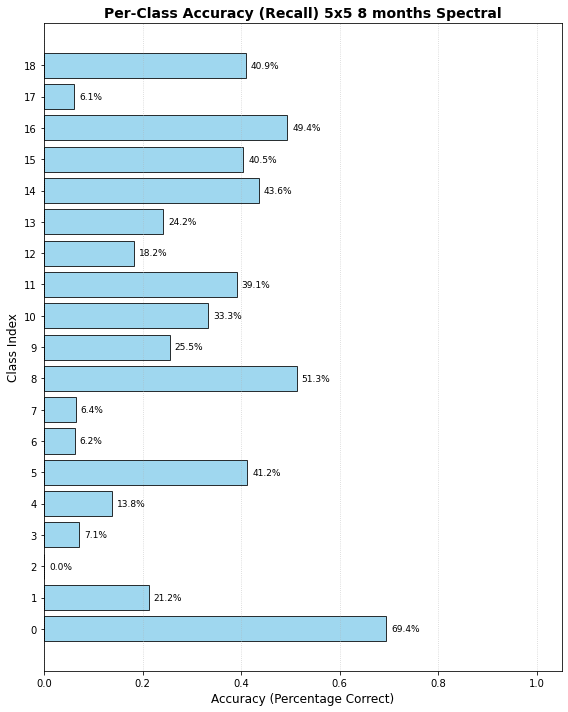

In [57]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

model_key = "PseTae_5x5_allyear_Spectral"

if model_key in test_results:
    data = test_results[model_key]
    cm = confusion_matrix(data['targets'], data['predictions'])
    
    # Calculate per-class accuracy: Diagonal elements / Row sums
    row_sums = cm.sum(axis=1)
    per_class_acc = np.diag(cm) / (row_sums + 1e-6) # Add small epsilon to avoid div by zero
    
    class_indices = np.arange(len(per_class_acc))
    
    # Plotting
    plt.figure(figsize=(8, 10))
    plt.barh(class_indices, per_class_acc, color='skyblue', edgecolor='black', alpha=0.8)
    
    # Formatting
    plt.title(f"Per-Class Accuracy (Recall) 5x5 8 months Spectral", fontsize=14, fontweight='bold')
    plt.xlabel("Accuracy (Percentage Correct)", fontsize=12)
    plt.ylabel("Class Index", fontsize=12)
    plt.yticks(class_indices)
    plt.xlim(0, 1.05)
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    
    # Add percentage labels
    for i, v in enumerate(per_class_acc):
        plt.text(v + 0.01, i, f"{v:.1%}", va='center', fontsize=9)
        
    plt.tight_layout()
    plt.savefig("per_class_accuracy_spectral.png", dpi=300)
    plt.show()
else:
    print(f"Model '{model_key}' not found in test_results.")

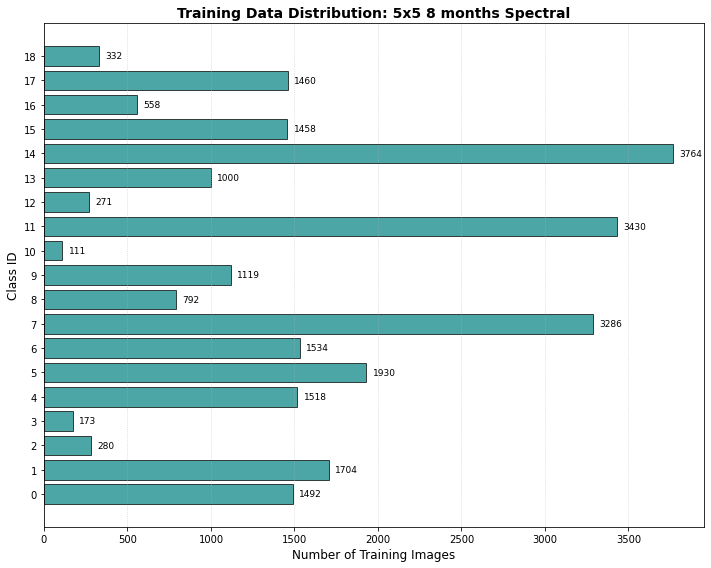

In [58]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import os
import pickle

# Target the spectral configuration
run = configs[0] # Assumes PseTae_5x5_allyear_Spectral is the first in your list
folder = run['folder']

# 1. Reload the dataset to get the labels
with open(os.path.join(folder, 'normalisation_values.pkl'), 'rb') as f:
    norm = pickle.load(f)

full_dataset = PixelSetData(folder=folder, labels="l3_species", npixel=run['npixel'], norm=norm)
all_labels = [int(full_dataset[i][1].item()) for i in range(len(full_dataset))]

# 2. Re-create the train/test split to get the exact counts used for training
# We use the same random_state=42 as in your prepare_dataloaders function
all_idx = list(range(len(full_dataset)))
train_idx, _, _, _ = train_test_split(
    all_idx, all_labels, test_size=0.30, random_state=42, stratify=all_labels
)

# 3. Count frequencies in the training subset
train_labels = [all_labels[i] for i in train_idx]
class_counts = Counter(train_labels)

# 4. Sort and Plot
sorted_classes = sorted(class_counts.items())
classes = [c[0] for c in sorted_classes]
counts = [c[1] for c in sorted_classes]

plt.figure(figsize=(10, 8))
plt.barh(classes, counts, color='teal', edgecolor='black', alpha=0.7)

plt.title(f"Training Data Distribution: 5x5 8 months Spectral", fontsize=14, fontweight='bold')
plt.xlabel("Number of Training Images", fontsize=12)
plt.ylabel("Class ID", fontsize=12)
plt.yticks(classes)
plt.grid(axis='x', linestyle=':', alpha=0.6)

# Add value labels
for i, count in enumerate(counts):
    plt.text(count + max(counts)*0.01, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.savefig("training_data_distribution.png", dpi=300)
plt.show()

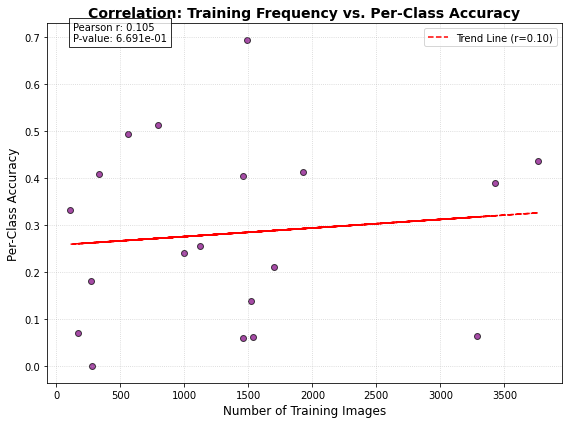

In [64]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Ensure your data is aligned by class index
# 'counts' should be the list of frequencies
# 'per_class_acc' should be the list of accuracies
# Note: Ensure these lists are the same length and sorted by the same class IDs.

# Calculate Pearson Correlation Coefficient
correlation, p_value = stats.pearsonr(counts, per_class_acc)

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(counts, per_class_acc, color='purple', alpha=0.7, edgecolors='black')

# Calculate and plot the trend line (linear regression)
m, b = np.polyfit(counts, per_class_acc, 1)
plt.plot(counts, m * np.array(counts) + b, color='red', linestyle='--', label=f'Trend Line (r={correlation:.2f})')

# Formatting
plt.title("Correlation: Training Frequency vs. Per-Class Accuracy", fontsize=14, fontweight='bold')
plt.xlabel("Number of Training Images", fontsize=12)
plt.ylabel("Per-Class Accuracy", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# Annotation
plt.text(0.05, 0.95, f"Pearson r: {correlation:.3f}\nP-value: {p_value:.3e}", 
         transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("correlation_analysis.png", dpi=300)
plt.show()